[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Tommy-Burns/easy-eo/blob/main/examples/03_real_world/03_urban_footprint_land_cover.ipynb)

# Urban footprint and land cover

Build a simple land-cover map by combining several indices, and see why the built-up index cannot be trusted on its own.

**The area.** Cairo - a dense city on the Nile, with irrigated floodplain on both banks and desert immediately beyond. Four land covers meet within a few kilometers, which makes the separations easy to see and the failure mode of NDBI impossible to ignore.

- **Data:** Sentinel-2 L2A from Microsoft Planetary Computer
- **Network: required.** This notebook queries a live catalog, so its outputs are not stored in the repository - run it yourself.
- **Requires:** `pip install "easy-eo[stac]"`

In [ ]:
# Running in Colab? Install Easy-EO. Does nothing anywhere else.
import sys

if "google.colab" in sys.modules:
    %pip install -q "easy-eo[stac]"


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

# Keeps the figures stored in this notebook small; raise it for print-quality output.
plt.rcParams["figure.dpi"] = 80

In [2]:
import numpy as np

import eeo

# Cairo — city, Nile floodplain, and desert
AOI = (31.20, 29.95, 31.32, 30.07)

results = eeo.stac_search(
    "sentinel-2-l2a", bbox=AOI, datetime="2023-08-01/2023-08-31", cloud_cover=1, limit=5
)

for item in results:
    print(f"{item.timestamp:%Y-%m-%d}  cloud {item.cloud_cover:.3f}%  {item.id}")

2023-08-06  cloud 0.002%  S2B_MSIL2A_20230806T082609_R021_T36RUU_20240907T101500
2023-08-26  cloud 0.003%  S2B_MSIL2A_20230826T082609_R021_T36RUU_20241025T124304
2023-08-26  cloud 0.002%  S2B_MSIL2A_20230826T082609_R021_T36RUU_20230826T152914
2023-08-31  cloud 0.002%  S2A_MSIL2A_20230831T082611_R021_T36RUU_20241017T210443
2023-08-31  cloud 0.001%  S2A_MSIL2A_20230831T082611_R021_T36RUU_20230831T163151


In [3]:
item = results[-1]
scene = item.load(["B03", "B04", "B08", "B11"])

scene.describe()

EEORasterDataset
  source      : <in-memory>
  driver      : GTiff
  bands       : 4
  band names  : 1: B03, 2: B04, 3: B08, 4: B11
  size        : 1348 × 1179  (height × width)
  dtype       : uint16
  crs         : EPSG:32636 — WGS 84 / UTM zone 36N
  pixel size  : 10 × 10  (CRS units)
  extent      : 326290, 3314430, 338080, 3327910  (minx, miny, maxx, maxy)
  nodata      : 0.0
  timestamp   : 2023-08-31T08:26:11.024000+00:00
  attrs       : stac_item=S2A_MSIL2A_20230831T082611_R021_T36RUU_20230831T163151, stac_collection=sentinel-2-l2a, stac_assets=['B03', 'B04', 'B08', 'B11']


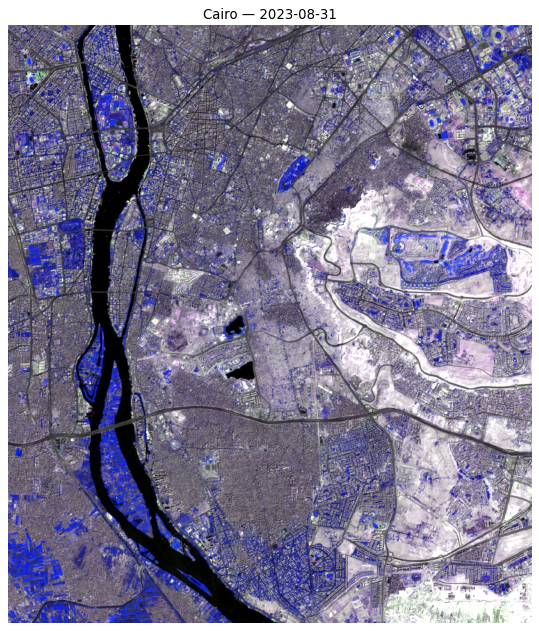

In [4]:
scene.plot_composite(["B04", "B03", "B08"], pmin=2, pmax=98,
                     title=f"Cairo — {item.timestamp:%Y-%m-%d}")

## NDBI, and why it is not enough

NDBI is `(SWIR1 - NIR) / (SWIR1 + NIR)`. Built surfaces reflect more short-wave infrared than near-infrared, so they come out positive.

So does bare soil. So does sand. The index does not measure "buildings" - it measures "dry, bright, non-vegetated", and a desert satisfies that just as well as a city does.

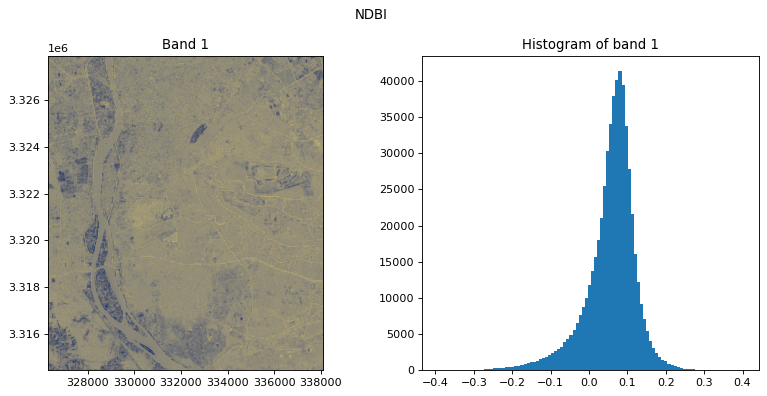

In [5]:
ndbi = scene.ndbi(nir="B08", swir="B11")
ndbi.plot_raster_with_histogram(cmap="cividis", bins=100, title="NDBI")

In [6]:
built_naive = ndbi.get_band(1) > 0
print(f"NDBI > 0 covers {built_naive.mean() * 100:.1f}% of the scene")
print("Cairo is dense, but it is not that dense — most of this is desert.")

NDBI > 0 covers 84.8% of the scene
Cairo is dense, but it is not that dense — most of this is desert.


That number is the whole lesson. Taken alone, NDBI classifies most of the Sahara as urban.

## Adding vegetation and water

The fix is not a better single index - it is a second axis. Vegetation (NDVI) separates the irrigated floodplain, and water (NDWI) separates the Nile.

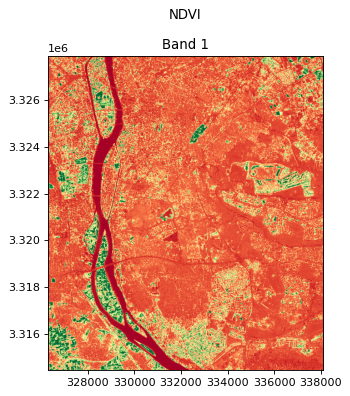

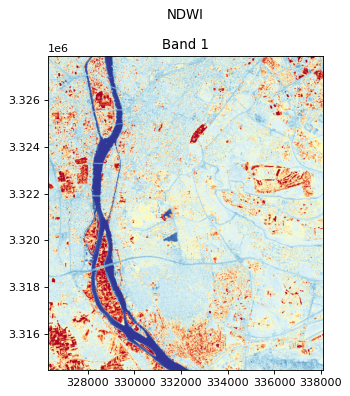

In [7]:
ndvi = scene.ndvi(red="B04", nir="B08")
ndwi = scene.ndwi(nir="B08", green="B03")

ndvi.plot_raster(cmap="RdYlGn", title="NDVI")
ndwi.plot_raster(cmap="RdYlBu", title="NDWI")

## Separating built-up from bare desert

Built surfaces and desert sand are both dry and non-vegetated, so no normalized-difference index will split them. What does differ is **brightness**: desert sand is considerably brighter in the visible bands than asphalt, concrete and shadowed streets.

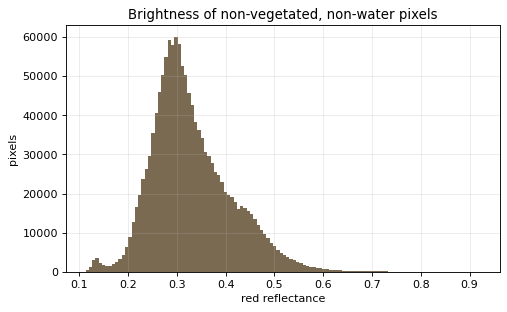

percentiles of red reflectance over non-vegetated ground:
  p10  0.240
  p25  0.274
  p50  0.314
  p75  0.376
  p90  0.445


In [8]:
brightness = scene.get_band("B04").astype("float32") / 10000

non_veg = (ndvi.get_band(1) < 0.2) & (ndwi.get_band(1) < 0)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(brightness[non_veg].ravel(), bins=120, color="#7a6a52")
ax.set_xlabel("red reflectance")
ax.set_ylabel("pixels")
ax.set_title("Brightness of non-vegetated, non-water pixels")
ax.grid(alpha=0.25)
plt.show()

print("percentiles of red reflectance over non-vegetated ground:")
for percentile in (10, 25, 50, 75, 90):
    print(f"  p{percentile:<3d} {np.percentile(brightness[non_veg], percentile):.3f}")

The distribution is broad, and the split between the darker built-up mode and the brighter sand is the threshold we want. Read it off the histogram rather than assuming a value - it depends on the sensor, the season and the sun angle.

In [9]:
BRIGHTNESS_SPLIT = 0.22    # adjust to the valley you see in the histogram above

ndvi_v = ndvi.get_band(1)
ndwi_v = ndwi.get_band(1)
ndbi_v = ndbi.get_band(1)

water = ndwi_v > 0
vegetation = (~water) & (ndvi_v > 0.25)
built_up = (~water) & (~vegetation) & (ndbi_v > 0) & (brightness < BRIGHTNESS_SPLIT)
desert = ~(water | vegetation | built_up)

pixel_area_km2 = abs(scene.get_transform().a * scene.get_transform().e) / 1e6

print(f"{'class':14s} {'share':>8s} {'area':>12s}")
for label, mask in (("water", water), ("vegetation", vegetation),
                    ("built-up", built_up), ("desert / bare", desert)):
    print(f"{label:14s} {mask.mean() * 100:7.1f}% {mask.sum() * pixel_area_km2:9.2f} km^2")

class             share         area
water              3.8%      6.10 km^2
vegetation         7.1%     11.32 km^2
built-up           4.7%      7.48 km^2
desert / bare     84.3%    134.03 km^2


Compare that built-up share with the 84% NDBI alone suggested.

## The classification

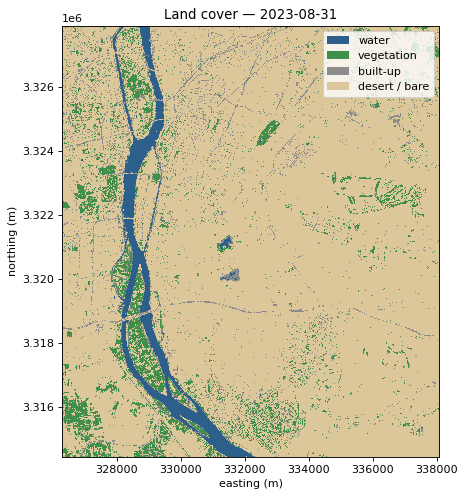

In [10]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

classes = np.full(water.shape, 3, dtype="uint8")   # default: desert
classes[water] = 0
classes[vegetation] = 1
classes[built_up] = 2

bounds = scene.get_bounds()
extent = (bounds.left, bounds.right, bounds.bottom, bounds.top)

colours = ["#2c5f8a", "#3f8f4a", "#8c8c8c", "#dcc79a"]
labels = ["water", "vegetation", "built-up", "desert / bare"]

fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(classes, cmap=ListedColormap(colours), vmin=0, vmax=3, extent=extent,
          interpolation="nearest")
ax.set_title(f"Land cover — {item.timestamp:%Y-%m-%d}")
ax.set_xlabel("easting (m)")
ax.set_ylabel("northing (m)")
ax.legend(handles=[Patch(facecolor=c, label=l) for c, l in zip(colours, labels)],
          loc="upper right")
plt.show()

## Checking the separation

Before believing a classification, look at how each class sits in the index space it was cut from. Classes that overlap heavily are classes the thresholds did not really separate.

In [11]:
print(f"{'class':14s} {'NDVI':>8s} {'NDWI':>8s} {'NDBI':>8s} {'red':>8s}")
for label, mask in (("water", water), ("vegetation", vegetation),
                    ("built-up", built_up), ("desert / bare", desert)):
    print(f"{label:14s} {ndvi_v[mask].mean():8.3f} {ndwi_v[mask].mean():8.3f} "
          f"{ndbi_v[mask].mean():8.3f} {brightness[mask].mean():8.3f}")

class              NDVI     NDWI     NDBI      red
water            -0.017    0.036    0.064    0.135
vegetation        0.353   -0.354   -0.086    0.195
built-up          0.103   -0.135    0.103    0.192
desert / bare     0.068   -0.140    0.065    0.333


Built-up and desert should differ clearly in red reflectance while sitting close together in NDBI - which is precisely the point: the brightness axis is doing the work NDBI could not.

## Saving it

In [12]:
import tempfile
from pathlib import Path

from eeo import load_array

out_dir = Path(tempfile.mkdtemp())

landcover = load_array(
    classes,
    crs=scene.get_crs(),
    transform=scene.get_transform(),
    band_names=["landcover"],
)
landcover.save_raster(str(out_dir / "landcover.tif"))
print("written:", out_dir / "landcover.tif")
landcover.describe()

written: /tmp/tmprda0c5ni/landcover.tif
EEORasterDataset
  source      : <in-memory>
  driver      : GTiff
  bands       : 1
  band names  : 1: landcover
  size        : 1348 × 1179  (height × width)
  dtype       : uint8
  crs         : EPSG:32636 — WGS 84 / UTM zone 36N
  pixel size  : 10 × 10  (CRS units)
  extent      : 326290, 3314430, 338080, 3327910  (minx, miny, maxx, maxy)
  nodata      : none
  timestamp   : none
  attrs       : none


## Caveats

- **Thresholds are scene-specific.** These values suit Cairo in August. Moving city, season or sensor moves the thresholds, which is exactly why real land cover mapping uses trained classifiers rather than fixed cuts.
- **No accuracy assessment.** A classification without validation against reference points is a picture, not a measurement.
- **Mixed pixels.** At 10 m, a pixel spanning a road and a garden is genuinely both, and a hard classification has to pick one.
- **Shadow** in dense city blocks is dark and non-vegetated, and can fall on either side of the brightness split.

In [13]:
for ds in (scene, ndvi, ndwi, ndbi, landcover):
    ds.close()
print("closed")

closed


## Next

- **[04_terrain_analysis_with_dem](04_terrain_analysis_with_dem.ipynb)** - bringing elevation into the analysis